# NILA Broadband — Subscriber Churn Prediction
## A worked capstone example · Bharathidasan Institute of Management
### Artificial Intelligence and Machine Learning · Term 4

---

## Why this notebook exists

This is a **complete, worked capstone from end to end**, built so you can see what "good" looks like
before you build your own. It is not a template to copy — the case is deliberately different from
anything in your assignment tracks. What you should take from it is the **shape**: the order of the
steps, the checks at each stage, and the honesty about what did not work.

## The one rule this notebook demonstrates above all others

> **Every claim is tested against a baseline, and every number is reported as it came out.**

You will see a model here that is **less accurate than doing nothing** and is still the right model to
ship. You will see the most sophisticated algorithm come last. You will see a targeting strategy that
**loses money** despite catching almost every churner. None of that is edited out, because that is the
part worth learning.

---

## How the course modules map onto this notebook

| Section | What happens | Module |
|---|---|---|
| 1 | Business understanding, CRISP-DM framing, cost of each error | 1 |
| 2 | Data acquisition, provenance, simulation note | 1 |
| 3 | Data audit: fill rate, descriptives, target balance, EDA | 2 |
| 4 | Missing values, outliers, skew and transformation | 2 |
| 5 | Feature engineering: Creation → Transformation → Extraction → Selection | 2 |
| 6 | NLP on support tickets: cleaning, TF-IDF, derived text features | 5 |
| 7 | Clustering and PCA used *as feature engineering* | 4 |
| 8 | Feature selection: correlation, iterative VIF, leakage audit | 2 |
| 9 | Stratified sampling and the train/test split | 2, 3 |
| 10 | Baseline first, then four supervised models | 3 |
| 11 | Cross-validation and Grid Search | 3 |
| 12 | Confusion matrix, threshold tuning, ROC, gain, decile, KS | 3 |
| 13 | Profit optimisation — converting the model into rupees | 3 |
| 14 | Explainability with SHAP | 5 |
| 15 | Deployment: drift monitoring, model card, saved artefact | 5 |
| 16 | Recommendation and honest limitations | 1, 5 |

---

# 1 · Business Understanding
### *Module 1 — CRISP-DM begins here, not with the data*

**NILA Broadband** is a fixed-line internet provider operating across six Tamil Nadu cities with about
190,000 subscribers. Growth has stalled: they acquire roughly as many subscribers each quarter as they
lose. The Chief Operating Officer, **Ms. Lakshmi Narayanan**, wants to stop the leak rather than keep
refilling the bucket.

### The decision this model informs

The retention team can call and offer a save package — a discount, a free speed upgrade, or a waived
installation fee — to a limited number of subscribers each month. **They cannot call everybody.** So
the question is not "who might leave" but **"which subscribers should we spend our limited retention
budget on this month?"**

That framing matters. It makes this a **ranking** problem before it is a classification problem, which
changes how we evaluate it later.

### Defining the target precisely

> A subscriber is **churned** if they terminate their connection, or fail to renew within 30 days of
> their billing cycle ending.

Ambiguity here is fatal. "Inactive" or "unhappy" would produce a different model and a different action.

### The economics — every error has a price

| | Value | Where it comes from |
|---|---|---|
| Average subscriber lifetime value | **₹14,400** | ₹800 average monthly bill × 18 month average life |
| Cost of one retention offer | **₹1,200** | Discount plus agent time |
| Success rate of an offer on a genuine churner | **35%** | Last year's campaign data |

So contacting a genuine churner is worth `0.35 × ₹14,400 − ₹1,200 = +₹3,840` in expectation.
Contacting somebody who was never going to leave costs `−₹1,200`.

**The ratio is roughly 3.2 to 1**, which tells us immediately that we should tolerate some false alarms
to catch churners — but not unlimited ones. Section 13 finds the exact point where that stops paying.

### Success criteria, agreed before any modelling

1. The model must **beat the naive baseline** of assuming nobody churns.
2. It must achieve **KS above 30** — the accepted minimum for a usable scorecard.
3. The recommended targeting policy must show a **positive net rupee return** on held-out data.
4. Every prediction must be **explainable** to a subscriber who asks why they were contacted.

---

# 2 · Data Acquisition and Provenance
### *Module 1 — where the data came from, stated honestly*

> ### A note you must read
>
> The dataset below is **simulated**, generated by a documented process with a fixed random seed so that
> every number in this notebook is reproducible. It is built to mirror the structure of a real ISP
> subscriber file — including realistic missingness, skew and a non-linear interaction.
>
> **Your capstone must use real public data.** Simulated data is used here only so that this teaching
> example runs identically on every machine with no downloads. In your own submission, this section
> would carry the full provenance record: publisher, URL, access date, coverage period, licence and
> known limitations.

In [1]:
# ============================================================
# SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 96, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
rng = np.random.default_rng(2026)
N = 6000

print("Environment ready. pandas", pd.__version__, "| numpy", np.__version__)

Environment ready. pandas 2.3.3 | numpy 1.26.4


In [2]:
# ============================================================
# SIMULATED SUBSCRIBER FILE  (documented generating process)
# ============================================================
city = rng.choice(["Tiruchirappalli","Chennai","Coimbatore","Madurai","Salem","Erode"],
                  N, p=[.19,.26,.17,.15,.12,.11])
plan = rng.choice(["Basic 50Mbps","Value 100Mbps","Pro 300Mbps","Ultra 1Gbps"], N, p=[.34,.33,.23,.10])
plan_price = pd.Series(plan).map({"Basic 50Mbps":499,"Value 100Mbps":799,
                                  "Pro 300Mbps":1199,"Ultra 1Gbps":2199}).values
contract   = rng.choice(["Monthly","Annual","Two-year"], N, p=[.52,.33,.15])
tenure     = np.clip(np.round(rng.gamma(2.0, 11, N)), 1, 84).astype(int)
age        = np.clip(np.round(rng.normal(38, 12, N)), 19, 78).astype(int)
household  = rng.choice([1,2,3,4,5,6], N, p=[.14,.24,.28,.20,.09,.05])
autopay    = rng.choice([0,1], N, p=[.42,.58])
devices    = np.clip(rng.poisson(4, N)+1, 1, 18)
monthly_gb = np.round(np.clip(rng.lognormal(5.5, .62, N), 12, 3000), 1)
outages    = rng.poisson(1.1, N)
speed_pct  = np.round(np.clip(rng.normal(87, 13, N), 28, 100), 1)
tickets    = rng.poisson(1.4, N)
days_tkt   = np.where(tickets > 0, np.clip(np.round(rng.exponential(48, N)), 1, 730), np.nan)
late_pay   = rng.poisson(0.7, N)
comp_km    = np.round(np.clip(rng.exponential(2.4, N), 0.1, 15), 2)

# ---- free-text support tickets (this becomes our Module 5 material) ----
TEMPLATES = {
 "speed":   ["speed very slow in evening","not getting promised speed","buffering during video calls",
             "download speed dropped badly","internet slow since last week"],
 "outage":  ["no connection since morning","frequent disconnection every day","line down again third time",
             "outage for two days no response","connection keeps dropping"],
 "billing": ["billed twice this month","charged extra amount not informed","refund not received yet",
             "bill amount higher than plan","autopay deducted wrong amount"],
 "install": ["technician did not arrive","installation delayed by a week","router not working after setup",
             "need relocation of connection","new connection pending"],
 "praise":  ["service is good and stable","happy with the speed","technician was helpful and quick",
             "no complaints working fine","good support response"],
}
TOPIC_P = {"speed":.30,"outage":.24,"billing":.19,"install":.12,"praise":.15}

def make_ticket(n_tickets, n_outage, speed):
    """Ticket wording depends on the subscriber's actual experience."""
    if n_tickets == 0:
        return ""
    parts = []
    for _ in range(min(int(n_tickets), 3)):
        if n_outage >= 3:      topic = "outage"
        elif speed < 70:       topic = "speed"
        else:                  topic = rng.choice(list(TOPIC_P), p=list(TOPIC_P.values()))
        parts.append(rng.choice(TEMPLATES[topic]))
    return " | ".join(parts)

ticket_text = [make_ticket(tickets[i], outages[i], speed_pct[i]) for i in range(N)]

# ---- churn generating process (a logistic model with one interaction) ----
contract_risk = pd.Series(contract).map({"Monthly":1.0,"Annual":0.25,"Two-year":0.0}).values
z = (-2.55
     + 1.75*contract_risk          # month-to-month subscribers leave easily
     - 0.040*tenure                # long-tenured subscribers are loyal
     + 0.40*outages                # service failures drive churn
     - 0.042*(speed_pct - 87)      # under-delivering on the promised speed
     + 0.30*late_pay
     - 0.70*autopay                # autopay creates inertia
     + 0.20*tickets
     - 0.14*comp_km                # a nearby competitor makes leaving easy
     + 0.00045*(plan_price - 800))
z += 1.25*((outages >= 3) & (speed_pct < 75))   # INTERACTION: bad service compounds
churn = (rng.random(N) < 1/(1+np.exp(-z))).astype(int)

df = pd.DataFrame({
 "subscriber_id": [f"NB{100000+i}" for i in range(N)],
 "city": city, "plan": plan, "plan_price_inr": plan_price, "contract_type": contract,
 "tenure_months": tenure, "age": age, "household_size": household,
 "autopay_enabled": autopay, "connected_devices": devices, "monthly_data_gb": monthly_gb,
 "outages_last_90d": outages, "avg_speed_pct_of_plan": speed_pct,
 "support_tickets_last_90d": tickets, "days_since_last_ticket": days_tkt,
 "late_payments_last_12m": late_pay, "competitor_distance_km": comp_km,
 "support_ticket_text": ticket_text, "churned": churn})

# realistic missingness: speed telemetry fails on some lines, household size is optional
df.loc[rng.choice(N, int(N*.06), replace=False), "avg_speed_pct_of_plan"] = np.nan
df.loc[rng.choice(N, int(N*.03), replace=False), "household_size"] = np.nan

print(f"Subscriber file built: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(4)

Subscriber file built: 6,000 rows x 19 columns


,subscriber_id,city,plan,plan_price_inr,contract_type,tenure_months,age,household_size,autopay_enabled,connected_devices,monthly_data_gb,outages_last_90d,avg_speed_pct_of_plan,support_tickets_last_90d,days_since_last_ticket,late_payments_last_12m,competitor_distance_km,support_ticket_text,churned
0,NB100000,Tiruchirappalli,Value 100Mbps,799,Annual,30,31,6.0,1,3,310.4,1,100.0,1,1.0,0,0.10,speed very slow in evening,0
1,NB100001,Madurai,Pro 300Mbps,1199,Two-year,9,32,1.0,1,2,159.6,0,59.0,1,10.0,1,4.32,internet slow since last week,1
2,NB100002,Coimbatore,Value 100Mbps,799,Annual,22,19,4.0,1,2,294.7,4,95.9,0,NaN,2,0.13,,1
3,NB100003,Chennai,Pro 300Mbps,1199,Annual,4,19,3.0,0,2,222.3,2,81.0,1,48.0,0,0.49,billed twice this month,0


# 3 · Data Understanding
### *Module 2 — audit before analysis, always*

In [3]:
# ---- 3.1 Fill rate: is this data usable at all? ----
fill = (df.notna().mean()*100).round(1).sort_values()
print("FILL RATE (%)")
print("-"*46)
print(fill.to_string())

print("\n\nDATA TYPES")
print("-"*46)
print(df.dtypes.to_string())
print("\nDuplicate rows:", df.duplicated().sum())

FILL RATE (%)
----------------------------------------------
days_since_last_ticket       75.4
avg_speed_pct_of_plan        94.0
household_size               97.0
subscriber_id               100.0
competitor_distance_km      100.0
late_payments_last_12m      100.0
support_tickets_last_90d    100.0
outages_last_90d            100.0
monthly_data_gb             100.0
connected_devices           100.0
autopay_enabled             100.0
age                         100.0
tenure_months               100.0
contract_type               100.0
plan_price_inr              100.0
plan                        100.0
city                        100.0
support_ticket_text         100.0
churned                     100.0


DATA TYPES
----------------------------------------------
subscriber_id                object
city                         object
plan                         object
plan_price_inr                int64
contract_type                object
tenure_months                 int32
age              

In [4]:
# ---- 3.2 Descriptive statistics ----
num_cols = ["tenure_months","age","household_size","connected_devices","monthly_data_gb",
            "outages_last_90d","avg_speed_pct_of_plan","support_tickets_last_90d",
            "late_payments_last_12m","competitor_distance_km","plan_price_inr"]
print("DESCRIPTIVE STATISTICS")
print(df[num_cols].describe().T[["count","mean","std","min","50%","max"]].round(2).to_string())

print("\n\nTARGET BALANCE")
print("-"*46)
vc = df.churned.value_counts()
for k, v in vc.items():
    print(f"  {'Churned' if k==1 else 'Retained':10} {v:>6,}  ({v/len(df)*100:.1f}%)")
print(f"\n>>> Churn rate is {df.churned.mean()*100:.1f}%. The classes are IMBALANCED,")
print(">>> so accuracy will be an unsafe headline metric from here on.")

DESCRIPTIVE STATISTICS
                           count    mean     std    min     50%     max
tenure_months             6000.0   21.89   15.24    1.0   18.00    84.0
age                       6000.0   38.40   11.25   19.0   38.00    78.0
household_size            5820.0    2.98    1.34    1.0    3.00     6.0
connected_devices         6000.0    4.99    2.00    1.0    5.00    13.0
monthly_data_gb           6000.0  295.95  204.18   21.7  246.25  2675.5
outages_last_90d          6000.0    1.09    1.06    0.0    1.00     6.0
avg_speed_pct_of_plan     5640.0   85.88   11.10   33.8   86.95   100.0
support_tickets_last_90d  6000.0    1.40    1.18    0.0    1.00     8.0
late_payments_last_12m    6000.0    0.68    0.82    0.0    0.00     6.0
competitor_distance_km    6000.0    2.42    2.42    0.1    1.67    15.0
plan_price_inr            6000.0  937.98  509.22  499.0  799.00  2199.0


TARGET BALANCE
----------------------------------------------
  Retained    4,968  (82.8%)
  Churned     1,032 

> ### What the audit tells us
>
> - `avg_speed_pct_of_plan` is **94.0% complete** and `household_size` **97.0%** — both need imputation.
> - `days_since_last_ticket` is only **~75% complete**, but that is *structural*: subscribers who never
>   raised a ticket have no such date. This is **not missing data — it is a meaningful absence**, and
>   treating it like an ordinary gap would be a mistake.
> - Churn sits at **17.2%**. Predicting "nobody churns" would therefore be **82.8% accurate** and catch
>   nobody. We record that number now and hold every model against it.

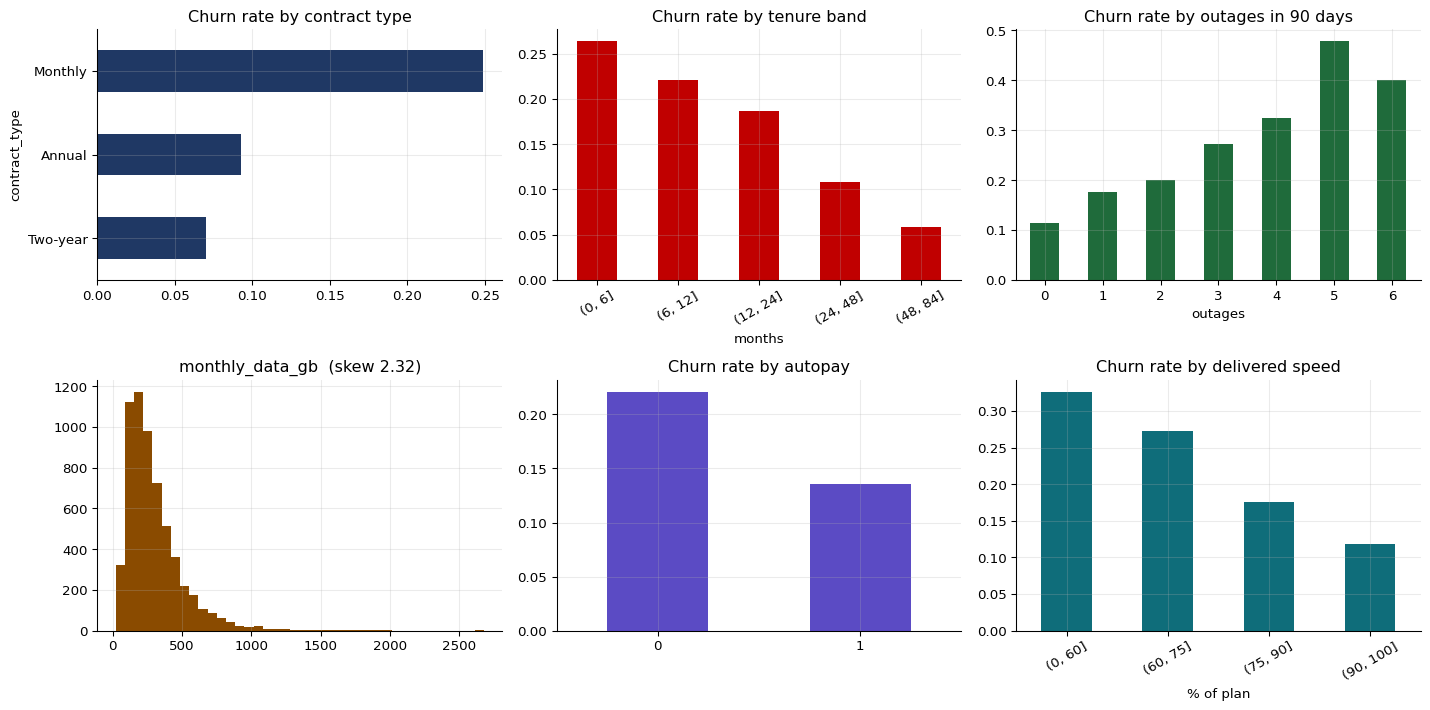

In [5]:
# ---- 3.3 EDA: what relates to churn? ----
fig, ax = plt.subplots(2, 3, figsize=(15, 7.5))

df.groupby("contract_type").churned.mean().sort_values().plot(
    kind="barh", ax=ax[0,0], color="#1F3864")
ax[0,0].set_title("Churn rate by contract type"); ax[0,0].set_xlabel("")

df.groupby(pd.cut(df.tenure_months, [0,6,12,24,48,84])).churned.mean().plot(
    kind="bar", ax=ax[0,1], color="#C00000")
ax[0,1].set_title("Churn rate by tenure band"); ax[0,1].set_xlabel("months"); ax[0,1].tick_params(axis="x", rotation=30)

df.groupby("outages_last_90d").churned.mean().head(7).plot(
    kind="bar", ax=ax[0,2], color="#1F6B3B")
ax[0,2].set_title("Churn rate by outages in 90 days"); ax[0,2].set_xlabel("outages"); ax[0,2].tick_params(axis="x", rotation=0)

ax[1,0].hist(df.monthly_data_gb, bins=40, color="#8A4B00")
ax[1,0].set_title(f"monthly_data_gb  (skew {df.monthly_data_gb.skew():.2f})")

df.groupby("autopay_enabled").churned.mean().plot(kind="bar", ax=ax[1,1], color="#5B4BC4")
ax[1,1].set_title("Churn rate by autopay"); ax[1,1].set_xlabel(""); ax[1,1].tick_params(axis="x", rotation=0)

df.groupby(pd.cut(df.avg_speed_pct_of_plan, [0,60,75,90,100])).churned.mean().plot(
    kind="bar", ax=ax[1,2], color="#0F6D7A")
ax[1,2].set_title("Churn rate by delivered speed"); ax[1,2].set_xlabel("% of plan"); ax[1,2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

> ### Reading the EDA
>
> Four business signals jump out before a single model is built:
>
> 1. **Contract type dominates.** Month-to-month subscribers churn several times more than two-year ones.
> 2. **Churn is front-loaded.** The first six to twelve months carry most of the risk; subscribers who
>    pass two years rarely leave.
> 3. **Service quality compounds.** Churn climbs steadily with outages, and jumps where delivered speed
>    falls below about 75% of the plan.
> 4. **Autopay creates inertia.** Subscribers on autopay churn markedly less — though note this is
>    correlation. Autopay may simply be a *marker* of committed subscribers rather than a cause of
>    commitment, and we return to this in the limitations.
>
> `monthly_data_gb` is heavily right-skewed and will need transforming.

# 4 · Data Preparation — cleaning
### *Module 2 — missing values, outliers, skew*

In [6]:
d = df.copy()

# ---- 4.1 Missing values: three different problems, three different treatments ----
print("BEFORE:", d[["avg_speed_pct_of_plan","household_size","days_since_last_ticket"]].isna().sum().to_dict())

# (a) telemetry gap -> median impute (median, not mean, because the column has a tail)
speed_median = d.avg_speed_pct_of_plan.median()
d["speed_was_imputed"] = d.avg_speed_pct_of_plan.isna().astype(int)   # keep an audit flag
d["avg_speed_pct_of_plan"] = d.avg_speed_pct_of_plan.fillna(speed_median)

# (b) optional field -> median impute
d["household_size"] = d.household_size.fillna(d.household_size.median())

# (c) STRUCTURAL absence -> a sentinel plus an explicit flag, NOT an average
d["ever_raised_ticket"] = (d.support_tickets_last_90d > 0).astype(int)
d["days_since_last_ticket"] = d.days_since_last_ticket.fillna(999)

print("AFTER :", d[["avg_speed_pct_of_plan","household_size","days_since_last_ticket"]].isna().sum().to_dict())
print(f"\nSpeed imputed with median = {speed_median:.1f}% on {d.speed_was_imputed.sum()} rows")
print("days_since_last_ticket filled with sentinel 999 + ever_raised_ticket flag")
print("\n>>> Imputing a 'days since ticket' average for someone who never raised one")
print(">>> would invent a customer-service history that never happened.")

BEFORE: {'avg_speed_pct_of_plan': 360, 'household_size': 180, 'days_since_last_ticket': 1475}
AFTER : {'avg_speed_pct_of_plan': 0, 'household_size': 0, 'days_since_last_ticket': 0}

Speed imputed with median = 87.0% on 360 rows
days_since_last_ticket filled with sentinel 999 + ever_raised_ticket flag

>>> Imputing a 'days since ticket' average for someone who never raised one
>>> would invent a customer-service history that never happened.


In [7]:
# ---- 4.2 Outliers via the IQR rule ----
Q1, Q3 = d.monthly_data_gb.quantile([.25, .75])
IQR = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
out = d[(d.monthly_data_gb < lo) | (d.monthly_data_gb > hi)]
print(f"Q1 {Q1:,.1f} GB   Q3 {Q3:,.1f} GB   IQR {IQR:,.1f}")
print(f"IQR fence: {max(lo,0):,.1f} to {hi:,.1f} GB")
print(f"Flagged as outliers: {len(out):,} subscribers ({len(out)/len(d)*100:.1f}%)")
print(f"Their churn rate: {out.churned.mean()*100:.1f}%  vs  {d.churned.mean()*100:.1f}% overall")

print("\n>>> DECISION: we do NOT cap these.")
print(">>> They are genuine heavy users, not data errors, and they are a commercially")
print(">>> important segment. Capping would erase real signal. Instead we log-transform,")
print(">>> which compresses the tail without discarding anyone.")

Q1 156.8 GB   Q3 372.9 GB   IQR 216.1
IQR fence: 0.0 to 697.1 GB
Flagged as outliers: 275 subscribers (4.6%)
Their churn rate: 16.7%  vs  17.2% overall

>>> DECISION: we do NOT cap these.
>>> They are genuine heavy users, not data errors, and they are a commercially
>>> important segment. Capping would erase real signal. Instead we log-transform,
>>> which compresses the tail without discarding anyone.


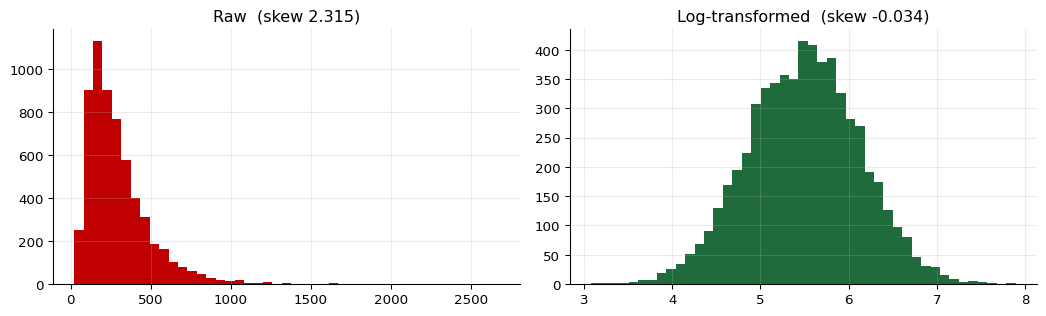

Skewness 2.315  ->  -0.034
Rule of thumb: beyond +/-1 is strongly skewed. We are now comfortably inside it.


In [8]:
# ---- 4.3 Transformation: fixing skew ----
d["data_gb_log"] = np.log(d.monthly_data_gb)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(d.monthly_data_gb, bins=45, color="#C00000")
ax[0].set_title(f"Raw  (skew {d.monthly_data_gb.skew():.3f})")
ax[1].hist(d.data_gb_log, bins=45, color="#1F6B3B")
ax[1].set_title(f"Log-transformed  (skew {d.data_gb_log.skew():.3f})")
plt.tight_layout(); plt.show()

print(f"Skewness {d.monthly_data_gb.skew():.3f}  ->  {d.data_gb_log.skew():.3f}")
print("Rule of thumb: beyond +/-1 is strongly skewed. We are now comfortably inside it.")

# 5 · Feature Engineering
### *Module 2 — the four stages, in the taught order*

**Creation → Transformation → Extraction → Selection.** Transformation was done in section 4.3, so we
pick up at Creation and run to Selection across sections 5 to 8.

In [9]:
# ---- STAGE 1: CREATION — ratios carry meaning that raw numbers hide ----
d["gb_per_device"]   = (d.monthly_data_gb / d.connected_devices).round(2)
d["price_per_gb"]    = (d.plan_price_inr / d.monthly_data_gb).round(3)
d["tickets_per_month"] = (d.support_tickets_last_90d / 3).round(3)
d["speed_deficit"]   = (100 - d.avg_speed_pct_of_plan).round(1)
d["value_score"]     = (d.avg_speed_pct_of_plan / d.plan_price_inr * 1000).round(3)

created = ["gb_per_device","price_per_gb","tickets_per_month","speed_deficit","value_score"]
print("CREATED FEATURES — mean by churn outcome")
print("-"*66)
comp = d.groupby("churned")[created].mean().round(3)
comp.index = ["Retained (0)","Churned (1)"]
print(comp.T.to_string())
print("\n>>> value_score (speed delivered per rupee) separates the groups: churners")
print(">>> are getting measurably less for their money.")

CREATED FEATURES — mean by churn outcome
------------------------------------------------------------------
                   Retained (0)  Churned (1)
gb_per_device            73.490       70.463
price_per_gb              4.654        5.095
tickets_per_month         0.451        0.542
speed_deficit            13.261       17.841
value_score             116.478      102.371

>>> value_score (speed delivered per rupee) separates the groups: churners
>>> are getting measurably less for their money.


In [10]:
# ---- STAGE 3: EXTRACTION (part 1) — encoding categorical variables ----
# ORDINAL where a real order exists
d["contract_ordinal"] = d.contract_type.map({"Monthly":0, "Annual":1, "Two-year":2})
d["plan_ordinal"]     = d.plan.map({"Basic 50Mbps":0, "Value 100Mbps":1,
                                    "Pro 300Mbps":2, "Ultra 1Gbps":3})
# ONE-HOT where no order exists — cities cannot be ranked
city_dummies = pd.get_dummies(d.city, prefix="city", drop_first=True).astype(int)
d = pd.concat([d, city_dummies], axis=1)

print("Ordinal encoded : contract_type (Monthly<Annual<Two-year), plan (by speed tier)")
print("One-hot encoded : city ->", list(city_dummies.columns))
print("\n>>> drop_first=True avoids the dummy variable trap. With all six city columns")
print(">>> present, any one is perfectly predictable from the other five, which would")
print(">>> give infinite VIF - exactly what section 8 is about to test for.")

Ordinal encoded : contract_type (Monthly<Annual<Two-year), plan (by speed tier)
One-hot encoded : city -> ['city_Coimbatore', 'city_Erode', 'city_Madurai', 'city_Salem', 'city_Tiruchirappalli']

>>> drop_first=True avoids the dummy variable trap. With all six city columns
>>> present, any one is perfectly predictable from the other five, which would
>>> give infinite VIF - exactly what section 8 is about to test for.


# 6 · Text Features from Support Tickets
### *Module 5 — turning language into numbers a model can use*

About a quarter of subscribers have raised a support ticket, and the wording carries information no
numeric column holds. A ticket saying *"line down again third time"* is a very different signal from
*"technician was helpful and quick"*, even though both count as one ticket.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

txt = d.support_ticket_text.fillna("")

# ---- 6.1 Simple derived features first (cheap and interpretable) ----
NEGATIVE_TERMS = ["slow","outage","down","disconnection","dropped","delayed",
                  "not","extra","refund","buffering","pending","wrong"]
d["ticket_char_len"]  = txt.str.len()
d["ticket_neg_terms"] = txt.apply(lambda s: sum(term in s for term in NEGATIVE_TERMS))

print("NEGATIVE-TERM COUNT vs CHURN")
print(d.groupby("ticket_neg_terms").agg(
    subscribers=("churned","size"), churn_rate=("churned","mean")).head(7).round(3).to_string())

# ---- 6.2 TF-IDF: weight words by how DISTINCTIVE they are ----
tfidf_vec = TfidfVectorizer(max_features=40, stop_words="english", min_df=5)
X_text = tfidf_vec.fit_transform(txt)
tfidf_df = pd.DataFrame(X_text.toarray(),
                        columns=[f"tf_{c}" for c in tfidf_vec.get_feature_names_out()],
                        index=d.index)

print(f"\nTF-IDF produced {tfidf_df.shape[1]} features from {len(txt):,} tickets")
print("Top terms by average weight:")
top = tfidf_df.mean().sort_values(ascending=False).head(10)
for term, w in top.items():
    print(f"   {term:<20} {w:.4f}")

NEGATIVE-TERM COUNT vs CHURN
                  subscribers  churn_rate
ticket_neg_terms                         
0                        2369       0.138
1                        1965       0.182
2                        1125       0.195
3                         418       0.222
4                         107       0.299
5                          16       0.250

TF-IDF produced 40 features from 6,000 tickets
Top terms by average weight:
   tf_speed             0.0946
   tf_connection        0.0910
   tf_slow              0.0642
   tf_week              0.0497
   tf_response          0.0493
   tf_morning           0.0413
   tf_evening           0.0407
   tf_time              0.0393
   tf_line              0.0393
   tf_technician        0.0385


> ### Why TF-IDF rather than a plain word count
>
> A raw count would rank words like *connection* and *speed* highest simply because they appear in
> almost every ticket — and a word present in every document separates nothing. TF-IDF divides that out
> and lifts terms that are frequent in *some* tickets but rare across the rest, which is where the
> signal lives.
>
> **A real-world caveat we would have to handle.** Actual NILA tickets would be code-mixed Tamil and
> English with transliteration and emoji. An English stopword list and an English tokeniser would
> silently mangle them, and a whole segment of subscribers would become invisible to the analysis.
> Our simulated tickets are clean English, so this notebook sidesteps a problem your real capstone may
> not be able to.

# 7 · Unsupervised Learning as Feature Engineering
### *Module 4 — clustering and PCA inside a supervised pipeline*

Clustering is usually taught as an end in itself. Here we use it differently: **the cluster a
subscriber belongs to becomes an input feature for the churn model.** This is common in practice —
segment membership captures combinations of behaviour that individual columns miss.

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

SEG_COLS = ["tenure_months","monthly_data_gb","plan_price_inr","connected_devices","outages_last_90d"]

# SCALING IS MANDATORY: rupees run to thousands, outages to single digits.
# Without it, plan_price would decide every cluster on its own.
seg_scaler = StandardScaler()
Z = seg_scaler.fit_transform(d[SEG_COLS])

print("CHOOSING k")
print("-"*44)
print(f"{'k':>3}{'inertia':>12}{'silhouette':>13}")
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    print(f"{k:>3}{km_k.inertia_:>12,.0f}{silhouette_score(Z, km_k.labels_):>13.3f}")

CHOOSING k
--------------------------------------------
  k     inertia   silhouette


  2      25,539        0.309


  3      21,724        0.212


  4      18,918        0.212


  5      16,390        0.224


  6      14,295        0.216


In [13]:
# NOTE the silhouettes are all modest (~0.2-0.3). That is normal for real behavioural
# data, where groups shade into each other rather than sitting in tidy balls.
# We choose k=4 not because a score told us to, but because the four groups have
# clearly different churn rates and would each get a different retention offer.
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(Z)
d["segment"] = kmeans.labels_

profile = d.groupby("segment").agg(
    subscribers=("churned","size"),
    tenure=("tenure_months","mean"),
    data_gb=("monthly_data_gb","mean"),
    price=("plan_price_inr","mean"),
    devices=("connected_devices","mean"),
    outages=("outages_last_90d","mean"),
    churn_rate=("churned","mean")).round(2)
print("SEGMENT PROFILE")
print(profile.to_string())

print("\n>>> A cluster number is not a segment until somebody can name it and act on it.")
print(">>> Reading the profile above, plausible names would be along the lines of:")
print(">>>   heavy long-tenured households · new light users · premium multi-device homes ·")
print(">>>   price-sensitive short-tenure subscribers")
print(">>> The retention offer should differ for each.")

SEGMENT PROFILE
         subscribers  tenure  data_gb    price  devices  outages  churn_rate
segment                                                                     
0               2944   15.46   298.73   789.01     5.06     0.51        0.16
1                985   46.52   291.48   792.71     4.75     0.83        0.07
2               1432   18.01   293.25   781.47     5.03     2.50        0.24
3                639   22.22   296.09  2199.00     5.01     1.05        0.24

>>> A cluster number is not a segment until somebody can name it and act on it.
>>> Reading the profile above, plausible names would be along the lines of:
>>>   heavy long-tenured households · new light users · premium multi-device homes ·
>>>   price-sensitive short-tenure subscribers
>>> The retention offer should differ for each.


Explained variance by component: [0.206 0.201] | cumulative: 0.407


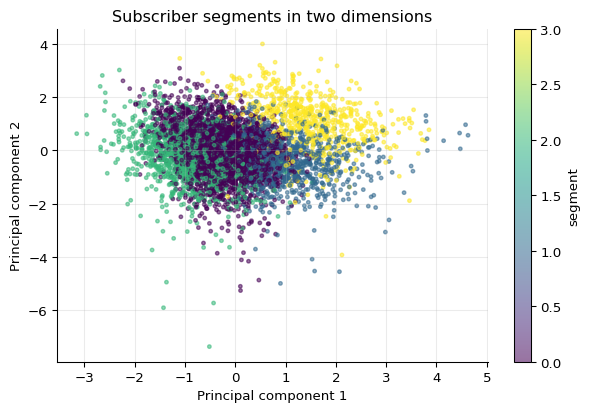


>>> PCA is used here ONLY for visualisation. We feed the model the segment
>>> label, not the components, because 'component 1' means nothing to a
>>> retention manager whereas 'premium multi-device home' does.


In [14]:
from sklearn.decomposition import PCA

# PCA on the segmentation space, purely to visualise the structure we just created
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Z)
print("Explained variance by component:", pca.explained_variance_ratio_.round(3),
      "| cumulative:", round(pca.explained_variance_ratio_.sum(), 3))

fig, ax = plt.subplots(figsize=(6.4, 4.4))
sc = ax.scatter(coords[:,0], coords[:,1], c=d.segment, cmap="viridis", s=7, alpha=.55)
ax.set_xlabel("Principal component 1"); ax.set_ylabel("Principal component 2")
ax.set_title("Subscriber segments in two dimensions")
plt.colorbar(sc, label="segment"); plt.tight_layout(); plt.show()

print("\n>>> PCA is used here ONLY for visualisation. We feed the model the segment")
print(">>> label, not the components, because 'component 1' means nothing to a")
print(">>> retention manager whereas 'premium multi-device home' does.")

# 8 · Feature Selection and the Leakage Audit
### *Module 2 — relevance, redundancy, and the question that kills models*

In [15]:
# ---- 8.1 THE LEAKAGE AUDIT — done before anything else ----
print("LEAKAGE AUDIT")
print("="*72)
print("For every feature: at the moment we make this prediction, would we have it?\n")
audit = [
 ("tenure_months",            "YES", "known from the billing system today"),
 ("outages_last_90d",         "YES", "historical network log, already recorded"),
 ("support_tickets_last_90d", "YES", "ticket system, backward-looking window"),
 ("avg_speed_pct_of_plan",    "YES", "telemetry averaged over the past period"),
 ("segment",                  "YES", "built only from features above"),
 ("tf_* (text)",              "YES", "tickets already raised, not future ones"),
 ("cancellation_date",        "NO",  "EXCLUDED - this IS the outcome"),
 ("final_bill_amount",        "NO",  "EXCLUDED - only exists after they leave"),
 ("retention_offer_accepted", "NO",  "EXCLUDED - happens after we predict"),
]
for f, ok, why in audit:
    print(f"  [{ok:>3}] {f:<26} {why}")
print("\n>>> The last three are not in our dataset. If they had been, each would have")
print(">>> produced a spectacular notebook score and a worthless production model.")

print("\n\nA SECOND, SUBTLER QUESTION: WHEN WAS EACH TRANSFORMER FITTED?")
print("="*72)
print("The speed median (4.1), the TF-IDF vocabulary (6.2), and the segmentation")
print("scaler and KMeans (7) were all fitted on ALL 6,000 rows - before section 9")
print("splits the data. None of them looks at 'churned', so this does not inflate")
print("the scores the way a leaked outcome column would, and every number below")
print("stands. It is still not what you would ship: in production each of these")
print("belongs INSIDE the Pipeline, refitted on the training rows of every fold, so")
print("that scoring a genuinely new subscriber uses nothing derived from their row.")
print("\n>>> They sit outside the pipeline here only so that each technique can be")
print(">>> taught, printed and inspected on its own. Your capstone should state")
print(">>> which of the two it is doing, and why.")

LEAKAGE AUDIT
For every feature: at the moment we make this prediction, would we have it?

  [YES] tenure_months              known from the billing system today
  [YES] outages_last_90d           historical network log, already recorded
  [YES] support_tickets_last_90d   ticket system, backward-looking window
  [YES] avg_speed_pct_of_plan      telemetry averaged over the past period
  [YES] segment                    built only from features above
  [YES] tf_* (text)                tickets already raised, not future ones
  [ NO] cancellation_date          EXCLUDED - this IS the outcome
  [ NO] final_bill_amount          EXCLUDED - only exists after they leave
  [ NO] retention_offer_accepted   EXCLUDED - happens after we predict

>>> The last three are not in our dataset. If they had been, each would have
>>> produced a spectacular notebook score and a worthless production model.


A SECOND, SUBTLER QUESTION: WHEN WAS EACH TRANSFORMER FITTED?
The speed median (4.1), the TF-IDF vocabul

In [16]:
# ---- 8.2 Relevance: correlation with the target ----
CANDIDATES = ["tenure_months","age","household_size","autopay_enabled","connected_devices",
 "data_gb_log","outages_last_90d","avg_speed_pct_of_plan","support_tickets_last_90d",
 "days_since_last_ticket","late_payments_last_12m","competitor_distance_km","plan_price_inr",
 "gb_per_device","price_per_gb","tickets_per_month","speed_deficit","value_score",
 "contract_ordinal","plan_ordinal","ever_raised_ticket","ticket_neg_terms","ticket_char_len",
 "segment","speed_was_imputed"] + list(city_dummies.columns)

corr = d[CANDIDATES + ["churned"]].corr()["churned"].drop("churned").sort_values(ascending=False)
print("CORRELATION WITH CHURN  (strongest first)")
print("-"*60)
for f, v in pd.concat([corr.head(8), corr.tail(8)]).items():
    bar = "#" * int(abs(v)*80)
    print(f"{f:<26}{v:>7.3f}  {bar}")

CORRELATION WITH CHURN  (strongest first)
------------------------------------------------------------
speed_deficit               0.161  ############
outages_last_90d            0.142  ###########
late_payments_last_12m      0.095  #######
segment                     0.089  #######
support_tickets_last_90d    0.087  ######
tickets_per_month           0.087  ######
ticket_char_len             0.085  ######
ticket_neg_terms            0.083  ######
gb_per_device              -0.015  #
days_since_last_ticket     -0.064  #####
competitor_distance_km     -0.091  #######
value_score                -0.109  ########
autopay_enabled            -0.111  ########
tenure_months              -0.151  ############
avg_speed_pct_of_plan      -0.161  ############
contract_ordinal           -0.202  ################


In [17]:
# ---- 8.3 Redundancy: iterative VIF pruning ----
from sklearn.linear_model import LinearRegression

def vif_table(frame, cols):
    X_ = frame[cols].astype(float)
    rows = []
    for c in cols:
        others = X_.drop(columns=[c])
        r2 = LinearRegression().fit(others, X_[c]).score(others, X_[c])
        rows.append((c, np.inf if r2 >= 0.999999 else 1/(1-r2)))
    return pd.DataFrame(rows, columns=["feature","VIF"]).sort_values("VIF", ascending=False)

print("VIF BEFORE PRUNING (top 8)")
print(vif_table(d, CANDIDATES).head(8).round(2).to_string(index=False))

# STEP 1 - drop the exact restatements WE created, keeping the interpretable original.
# Doing this explicitly (rather than letting the loop pick arbitrarily) means the
# surviving feature is the one a business reader can understand.
EXACT_DUPLICATES = {
 "speed_deficit":      "= 100 - avg_speed_pct_of_plan",
 "tickets_per_month":  "= support_tickets_last_90d / 3",
 "ever_raised_ticket": "determined by days_since_last_ticket sentinel we set in 4.1",
}
selected = [c for c in CANDIDATES if c not in EXACT_DUPLICATES]
print("\nSTEP 1 - removed by inspection (we built these ourselves):")
for f, why in EXACT_DUPLICATES.items():
    print(f"   {f:<22} {why}")

# STEP 2 - iterative pruning for whatever redundancy remains
dropped = []
while True:
    v = vif_table(d, selected)
    worst = v.iloc[0]
    if not np.isfinite(worst.VIF) or worst.VIF > 10:
        selected.remove(worst.feature)
        dropped.append((worst.feature, worst.VIF))
    else:
        break

print("\nSTEP 2 - removed by iterative VIF:")
for f, val in dropped:
    print(f"   {f:<22} VIF was {'inf' if not np.isfinite(val) else f'{val:,.1f}'}")
print("\nVIF AFTER PRUNING (top 6) - all now below 10")
print(vif_table(d, selected).head(6).round(2).to_string(index=False))
print(f"\nFeatures retained: {len(selected)} of {len(CANDIDATES)}")

VIF BEFORE PRUNING (top 8)


                 feature   VIF
       tickets_per_month   inf
   avg_speed_pct_of_plan   inf
       speed_was_imputed   inf
           speed_deficit   inf
support_tickets_last_90d   inf
      ever_raised_ticket 99.22
  days_since_last_ticket 97.74
            plan_ordinal 84.90

STEP 1 - removed by inspection (we built these ourselves):
   speed_deficit          = 100 - avg_speed_pct_of_plan
   tickets_per_month      = support_tickets_last_90d / 3
   ever_raised_ticket     determined by days_since_last_ticket sentinel we set in 4.1



STEP 2 - removed by iterative VIF:
   plan_ordinal           VIF was 84.9
   ticket_char_len        VIF was 15.8
   plan_price_inr         VIF was 10.4

VIF AFTER PRUNING (top 6) - all now below 10
                 feature  VIF
             data_gb_log 3.98
            price_per_gb 3.88
support_tickets_last_90d 2.52
           gb_per_device 2.29
                 segment 2.03
             value_score 2.02

Features retained: 24 of 30


> ### What the VIF pruning actually caught
>
> Look at what got dropped and *why* — each is a different lesson:
>
> - **`speed_deficit`** is literally `100 − avg_speed_pct_of_plan`. Two columns, one piece of
>   information, infinite VIF.
> - **`tickets_per_month`** is `support_tickets_last_90d ÷ 3`. Same thing.
> - **`ever_raised_ticket`** is determined by `days_since_last_ticket`, because *we created that
>   relationship ourselves* in section 4.1 when we filled the sentinel 999. **Our own imputation choice
>   manufactured the collinearity.** Worth pausing on — a defensible cleaning decision created a
>   downstream problem that only VIF revealed.
>
> Then the iterative pass removed three more: **`plan_ordinal`** (VIF 84.9) and **`plan_price_inr`**
> (10.4), which encode the same four-tier plan structure twice, and **`ticket_char_len`**, which tracks
> the ticket count almost exactly. Twenty-four of the original thirty tabular features survived.
>
> Feature Creation deliberately generates candidates. Feature Selection is where the redundant ones are
> removed. Doing the first without the second is how models become unstable and unexplainable.

# 9 · Sampling and the Train/Test Split
### *Modules 2 and 3 — stratification, and why not a time split here*

In [18]:
from sklearn.model_selection import train_test_split

X = pd.concat([d[selected], tfidf_df], axis=1)
y = d.churned

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"Total features : {X.shape[1]}  ({len(selected)} tabular + {tfidf_df.shape[1]} text)")
print(f"Training set   : {X_train.shape[0]:,} subscribers   churn {y_train.mean()*100:.1f}%")
print(f"Test set       : {X_test.shape[0]:,} subscribers   churn {y_test.mean()*100:.1f}%")
print("\n>>> stratify=y keeps the churn proportion identical in both halves. Without it,")
print(">>> a random split could hand the test set an unrepresentative churn rate and make")
print(">>> the evaluation meaningless.")
print("\n>>> WHY NOT A TIME SPLIT: this is a cross-sectional snapshot - one row per")
print(">>> subscriber, no time ordering. If we had monthly observations per subscriber,")
print(">>> a random split would leak the future and we would have to split by date.")

Total features : 64  (24 tabular + 40 text)
Training set   : 4,500 subscribers   churn 17.2%
Test set       : 1,500 subscribers   churn 17.2%

>>> stratify=y keeps the churn proportion identical in both halves. Without it,
>>> a random split could hand the test set an unrepresentative churn rate and make
>>> the evaluation meaningless.

>>> WHY NOT A TIME SPLIT: this is a cross-sectional snapshot - one row per
>>> subscriber, no time ordering. If we had monthly observations per subscriber,
>>> a random split would leak the future and we would have to split by date.


# 10 · Baseline First, Then Models
### *Module 3 — a model that beats nothing has proved nothing*

In [19]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve)

# ---- 10.1 THE BASELINE: assume nobody ever churns ----
baseline_pred = np.zeros(len(y_test), dtype=int)
print("BASELINE — 'nobody churns'")
print("-"*50)
print(f"  Accuracy : {accuracy_score(y_test, baseline_pred)*100:.1f}%")
print(f"  Recall   : {recall_score(y_test, baseline_pred, zero_division=0)*100:.1f}%")
print(f"  Churners caught: 0 of {int(y_test.sum())}")
print("\n>>> 82.8% accurate and completely useless. Every model below must be")
print(">>> judged against this, not against 100%.")

BASELINE — 'nobody churns'
--------------------------------------------------
  Accuracy : 82.8%
  Recall   : 0.0%
  Churners caught: 0 of 258

>>> 82.8% accurate and completely useless. Every model below must be
>>> judged against this, not against 100%.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# class_weight="balanced" tells the model that churners are rare and expensive to miss.
# Without it, every model drifts towards the lazy baseline.
models = {
 "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                  ("clf", LogisticRegression(max_iter=3000, class_weight="balanced",
                                                             random_state=RANDOM_STATE))]),
 "Decision Tree":       DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                               random_state=RANDOM_STATE),
 "Random Forest":       RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=5,
                                               class_weight="balanced", n_jobs=-1,
                                               random_state=RANDOM_STATE),
 "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = [["[BASELINE] nobody churns", accuracy_score(y_test, baseline_pred), 0.0, 0.0, 0.0, 0.500]]
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append([name, accuracy_score(y_test, pred), precision_score(y_test, pred, zero_division=0),
                 recall_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)])

results = pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1","AUC"]).round(3)
print("TEST-SET PERFORMANCE")
print("="*82)
print(results.to_string(index=False))

TEST-SET PERFORMANCE
                   Model  Accuracy  Precision  Recall    F1   AUC
[BASELINE] nobody churns     0.828      0.000   0.000 0.000 0.500
     Logistic Regression     0.717      0.342   0.698 0.459 0.770
           Decision Tree     0.683      0.292   0.589 0.390 0.687
           Random Forest     0.808      0.440   0.422 0.431 0.757
       Gradient Boosting     0.836      0.577   0.174 0.268 0.754


> ### The most important table in this notebook — read it slowly
>
> - **Logistic Regression is the LEAST accurate model here (0.717), below even the baseline's 0.828.**
>   It is also, on these numbers, the best model — it catches **70% of churners** where the baseline
>   catches none. It sacrifices accuracy on the easy retained majority to find the rare, expensive cases.
>
> - **Gradient Boosting has the HIGHEST accuracy (0.836) and is nearly useless.** It has essentially
>   rediscovered the baseline: high accuracy, recall of just 0.174 — it finds fewer than one churner in five. The most sophisticated algorithm
>   on the list produced the worst business outcome, because it was not told that churners matter more.
>
> - **AUC tells a cleaner story than accuracy.** Logistic Regression leads at 0.770. AUC measures how
>   well the model *ranks* subscribers by risk, which is exactly what our capped retention budget needs.
>
> **This is the central lesson of Module 3 in one table: on imbalanced data, accuracy rewards ignoring
> the very thing you are trying to find.**

# 11 · Cross-Validation and Grid Search
### *Module 3 — one number is not a result*

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("5-FOLD CROSS-VALIDATED F1  (on the training set only)")
print("="*72)
for name, model in fitted.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    print(f"{name:<22} {np.round(scores,3)}  mean {scores.mean():.3f}  sd {scores.std():.3f}")

print("\n>>> Report the mean AND the spread. A model whose folds swing widely is")
print(">>> unstable, and a single headline number for it would mislead the board.")

5-FOLD CROSS-VALIDATED F1  (on the training set only)


Logistic Regression    [0.468 0.461 0.458 0.463 0.435]  mean 0.457  sd 0.012


Decision Tree          [0.406 0.407 0.407 0.381 0.383]  mean 0.397  sd 0.012


Random Forest          [0.459 0.47  0.474 0.421 0.425]  mean 0.450  sd 0.023


Gradient Boosting      [0.287 0.25  0.205 0.288 0.283]  mean 0.263  sd 0.032

>>> Report the mean AND the spread. A model whose folds swing widely is
>>> unstable, and a single headline number for it would mislead the board.


In [22]:
# ---- Grid Search: tune against cross-validation, never against the test set ----
grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    param_grid={"max_depth":[6,10,14], "min_samples_leaf":[2,5,10]},
    cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("GRID SEARCH — 9 combinations x 5 folds = 45 fits")
print("-"*56)
print("Best parameters :", grid.best_params_)
print(f"Best CV F1      : {grid.best_score_:.3f}")
tuned_f1 = f1_score(y_test, grid.best_estimator_.predict(X_test))
print(f"Tuned RF test F1: {tuned_f1:.3f}")
print("\n>>> Tuning is done on cross-validation folds. The test set stays untouched")
print(">>> until the model is final - otherwise its score is no longer honest.")

GRID SEARCH — 9 combinations x 5 folds = 45 fits
--------------------------------------------------------
Best parameters : {'max_depth': 6, 'min_samples_leaf': 10}
Best CV F1      : 0.464
Tuned RF test F1: 0.442

>>> Tuning is done on cross-validation folds. The test set stays untouched
>>> until the model is final - otherwise its score is no longer honest.


# 12 · Evaluation in Depth
### *Module 3 — confusion matrix, threshold, ROC, gain, decile, KS*

We take **Logistic Regression** forward. It has the best AUC and recall, it is explainable to a
regulator and to a subscriber, and section 11 shows its fold-to-fold spread is the tightest of the
models worth shipping — the Decision Tree matches that spread, but from a mean well below it.

In [23]:
champion = fitted["Logistic Regression"]
proba = champion.predict_proba(X_test)[:, 1]
pred_default = (proba >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, pred_default).ravel()
print("CONFUSION MATRIX at the default 0.50 threshold")
print("="*62)
print(f"{'':<22}{'Predicted stay':>16}{'Predicted churn':>18}")
print(f"{'Actually stayed':<22}{tn:>16,}{fp:>18,}")
print(f"{'Actually churned':<22}{fn:>16,}{tp:>18,}")
print(f"\n  True positives  {tp:>5,}  churners we caught")
print(f"  False positives {fp:>5,}  loyal subscribers we would bother")
print(f"  False negatives {fn:>5,}  churners we MISSED - the expensive error")
print(f"  True negatives  {tn:>5,}  correctly left alone")
print(f"\n  Precision {tp/(tp+fp):.3f}   Recall {tp/(tp+fn):.3f}   F1 {f1_score(y_test,pred_default):.3f}")

CONFUSION MATRIX at the default 0.50 threshold
                        Predicted stay   Predicted churn
Actually stayed                    896               346
Actually churned                    78               180

  True positives    180  churners we caught
  False positives   346  loyal subscribers we would bother
  False negatives    78  churners we MISSED - the expensive error
  True negatives    896  correctly left alone

  Precision 0.342   Recall 0.698   F1 0.459


In [24]:
# ---- Threshold sweep: 0.50 is a business choice, not a law of nature ----
print("MOVING THE THRESHOLD")
print("="*84)
print(f"{'Thresh':>8}{'Contacted':>11}{'Caught':>9}{'Bothered':>10}{'Missed':>9}{'Precision':>11}{'Recall':>9}")
print("-"*84)
sweep = []
for t in [0.20,0.30,0.40,0.50,0.60,0.70,0.80]:
    pr = (proba >= t).astype(int)
    a,b,c,e = confusion_matrix(y_test, pr).ravel()
    prec = e/(e+b) if e+b else 0
    rec  = e/(e+c) if e+c else 0
    sweep.append((t, pr.sum(), e, b, c, prec, rec))
    print(f"{t:>8.2f}{pr.sum():>11,}{e:>9,}{b:>10,}{c:>9,}{prec:>11.3f}{rec:>9.3f}")
print("\n>>> Lower threshold = catch more churners, bother far more loyal subscribers.")
print(">>> Section 13 decides where that trade stops paying, in rupees.")

MOVING THE THRESHOLD
  Thresh  Contacted   Caught  Bothered   Missed  Precision   Recall
------------------------------------------------------------------------------------
    0.20      1,100      240       860       18      0.218    0.930
    0.30        898      222       676       36      0.247    0.860
    0.40        693      206       487       52      0.297    0.798
    0.50        526      180       346       78      0.342    0.698
    0.60        357      139       218      119      0.389    0.539
    0.70        215      101       114      157      0.470    0.391
    0.80        104       59        45      199      0.567    0.229

>>> Lower threshold = catch more churners, bother far more loyal subscribers.
>>> Section 13 decides where that trade stops paying, in rupees.


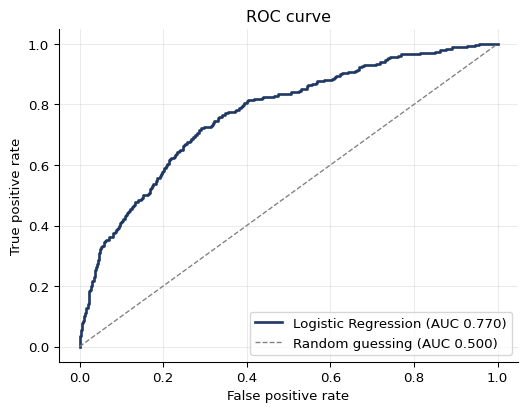

AUC = 0.770. Interpretation: given one churner and one non-churner at random,
the model ranks the churner as riskier 77.0% of the time.


In [25]:
# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.plot(fpr, tpr, color="#1F3864", lw=2, label=f"Logistic Regression (AUC {auc:.3f})")
ax.plot([0,1],[0,1], "--", color="grey", lw=1, label="Random guessing (AUC 0.500)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print(f"AUC = {auc:.3f}. Interpretation: given one churner and one non-churner at random,")
print(f"the model ranks the churner as riskier {auc*100:.1f}% of the time.")

In [26]:
# ---- DECILE, GAIN AND KS — how credit and telecom risk is actually reported ----
rank = pd.DataFrame({"actual": y_test.values, "prob": proba}) \
        .sort_values("prob", ascending=False).reset_index(drop=True)
rank["decile"] = pd.qcut(rank.index, 10, labels=range(1, 11))

dec = rank.groupby("decile", observed=False).agg(
        subscribers=("actual","size"), churners=("actual","sum")).reset_index()
total_ch = dec.churners.sum()
overall  = total_ch / dec.subscribers.sum()
dec["churn_rate_pct"]  = (dec.churners/dec.subscribers*100).round(1)
dec["lift"]            = (dec.churners/dec.subscribers/overall).round(2)
dec["cum_pct_churn"]   = (dec.churners.cumsum()/total_ch*100).round(1)
dec["cum_pct_retain"]  = ((dec.subscribers-dec.churners).cumsum() /
                          (dec.subscribers.sum()-total_ch)*100).round(1)
dec["KS"]              = (dec.cum_pct_churn - dec.cum_pct_retain).round(1)

print("DECILE TABLE — subscribers ranked riskiest (1) to safest (10)")
print("="*88)
print(dec.to_string(index=False))
print(f"\nOverall churn rate {overall*100:.1f}%   |   KS = {dec.KS.max():.1f} at decile {dec.loc[dec.KS.idxmax(),'decile']}")
print("Scorecard rule of thumb:  KS < 30 weak  |  30-50 acceptable  |  > 50 strong")

DECILE TABLE — subscribers ranked riskiest (1) to safest (10)
decile  subscribers  churners  churn_rate_pct  lift  cum_pct_churn  cum_pct_retain   KS
     1          150        85            56.7  3.29           32.9             5.2 27.7
     2          150        40            26.7  1.55           48.4            14.1 34.3
     3          150        38            25.3  1.47           63.2            23.1 40.1
     4          150        29            19.3  1.12           74.4            32.9 41.5
     5          150        19            12.7  0.74           81.8            43.4 38.4
     6          150        11             7.3  0.43           86.0            54.6 31.4
     7          150        12             8.0  0.47           90.7            65.7 25.0
     8          150        14             9.3  0.54           96.1            76.7 19.4
     9          150         6             4.0  0.23           98.4            88.2 10.2
    10          150         4             2.7  0.16       

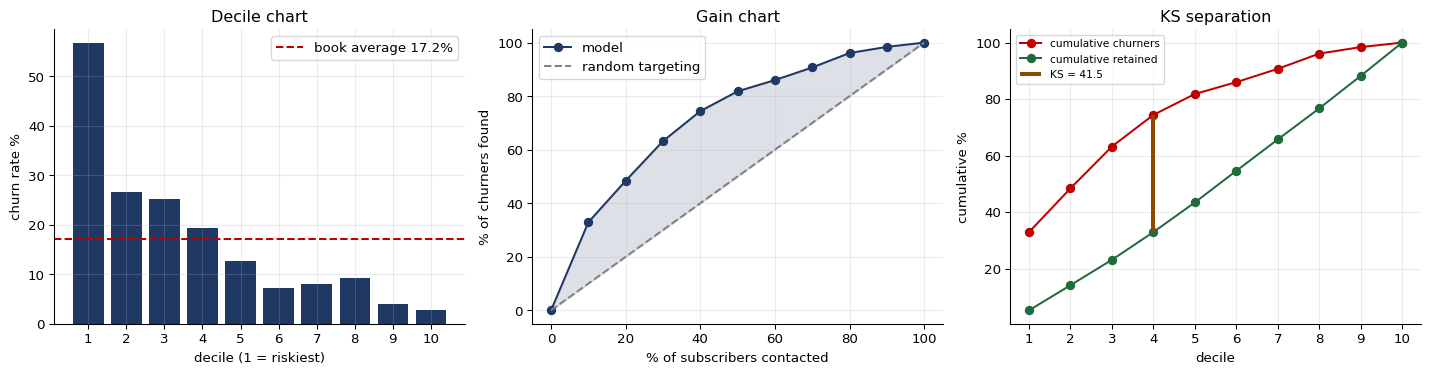

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].bar(range(1,11), dec.churn_rate_pct, color="#1F3864")
ax[0].axhline(overall*100, ls="--", color="#C00000", label=f"book average {overall*100:.1f}%")
ax[0].set_title("Decile chart"); ax[0].set_xlabel("decile (1 = riskiest)")
ax[0].set_ylabel("churn rate %"); ax[0].set_xticks(range(1,11)); ax[0].legend()

ax[1].plot([0]+list(range(10,101,10)), [0]+list(dec.cum_pct_churn), "o-", color="#1F3864", label="model")
ax[1].plot([0,100],[0,100], "--", color="grey", label="random targeting")
ax[1].fill_between([0]+list(range(10,101,10)), [0]+list(dec.cum_pct_churn),
                   [0]+list(range(10,101,10)), alpha=.15, color="#1F3864")
ax[1].set_title("Gain chart"); ax[1].set_xlabel("% of subscribers contacted")
ax[1].set_ylabel("% of churners found"); ax[1].legend()

ax[2].plot(range(1,11), dec.cum_pct_churn, "o-", color="#C00000", label="cumulative churners")
ax[2].plot(range(1,11), dec.cum_pct_retain, "o-", color="#1F6B3B", label="cumulative retained")
kmax = int(dec.KS.idxmax())
ax[2].vlines(kmax+1, dec.cum_pct_retain[kmax], dec.cum_pct_churn[kmax],
             color="#8A4B00", lw=3, label=f"KS = {dec.KS.max():.1f}")
ax[2].set_title("KS separation"); ax[2].set_xlabel("decile"); ax[2].set_ylabel("cumulative %")
ax[2].set_xticks(range(1,11)); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

> ### What the retention team would take from this
>
> - **Decile 1 churns at 56.7% against a book average of 17.2% — a lift of 3.29.** The ranking works.
> - The rate falls from 56.7% to under 5% across the deciles. It is not perfectly monotonic — deciles
>   7 and 8 tick up slightly — which is normal at 150 subscribers per decile and worth reporting rather
>   than smoothing over.
> - **Contact only the top 30% of the list and you reach 63.2% of all churners.** That single sentence
>   is the business case for the whole project.
> - **KS of 41.5**, peaking at decile 4, puts this in the acceptable band for a first-generation scorecard.

# 13 · From Probabilities to Rupees
### *Module 3 applied — the number the board actually decides on*

Every metric so far has been a ratio. Boards do not fund ratios. Using the economics agreed in
section 1, we find the threshold that maximises money rather than recall.

In [28]:
CLV            = 14_400   # lifetime value of a retained subscriber
OFFER_COST     =  1_200   # cost of one retention offer
SAVE_RATE      =   0.35   # offers that succeed on a genuine churner

print(f"Save a churner  : 0.35 x Rs {CLV:,} - Rs {OFFER_COST:,} = +Rs {SAVE_RATE*CLV-OFFER_COST:,.0f}")
print(f"Bother a loyal  : -Rs {OFFER_COST:,}")
print(f"Cost ratio      : {(SAVE_RATE*CLV-OFFER_COST)/OFFER_COST:.1f} to 1\n")

print(f"{'Thresh':>8}{'Contacted':>11}{'Saved':>8}{'Wasted':>9}{'Revenue Rs':>14}{'Cost Rs':>12}{'NET Rs':>14}")
print("="*80)
best = None
for t in [0.15,0.20,0.25,0.30,0.40,0.50,0.60,0.70,0.80]:
    pr = (proba >= t).astype(int)
    a,b,c,e = confusion_matrix(y_test, pr).ravel()
    contacted = int(pr.sum())
    saved     = e * SAVE_RATE
    revenue   = saved * CLV
    cost      = contacted * OFFER_COST
    net       = revenue - cost
    print(f"{t:>8.2f}{contacted:>11,}{saved:>8.0f}{b:>9,}{revenue:>14,.0f}{cost:>12,.0f}{net:>14,.0f}")
    if best is None or net > best[1]:
        best = (t, net, contacted, e, b)

print("="*80)
print(f"\nOPTIMAL THRESHOLD: {best[0]:.2f}")
print(f"  Contact {best[2]:,} of {len(y_test):,} subscribers")
print(f"  Catch {best[3]} genuine churners, bother {best[4]:,} loyal ones")
print(f"  NET RETURN: Rs {best[1]:,.0f} on this test set of {len(y_test):,} subscribers")

Save a churner  : 0.35 x Rs 14,400 - Rs 1,200 = +Rs 3,840
Bother a loyal  : -Rs 1,200
Cost ratio      : 3.2 to 1

  Thresh  Contacted   Saved   Wasted    Revenue Rs     Cost Rs        NET Rs
    0.15      1,207      87      958     1,254,960   1,448,400      -193,440
    0.20      1,100      84      860     1,209,600   1,320,000      -110,400
    0.25        997      81      766     1,164,240   1,196,400       -32,160
    0.30        898      78      676     1,118,880   1,077,600        41,280
    0.40        693      72      487     1,038,240     831,600       206,640
    0.50        526      63      346       907,200     631,200       276,000
    0.60        357      49      218       700,560     428,400       272,160
    0.70        215      35      114       509,040     258,000       251,040
    0.80        104      21       45       297,360     124,800       172,560

OPTIMAL THRESHOLD: 0.50
  Contact 526 of 1,500 subscribers
  Catch 180 genuine churners, bother 346 loyal ones
  NE

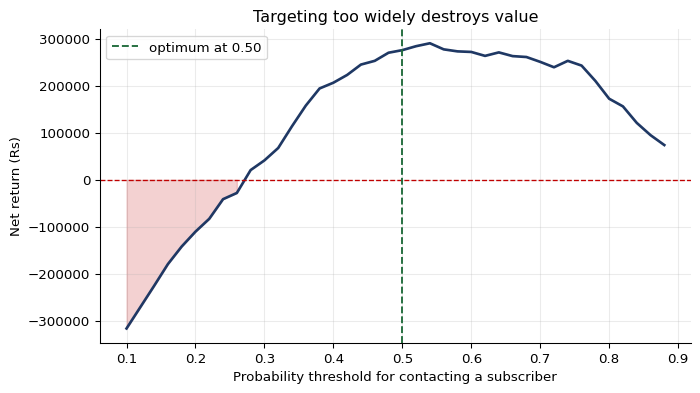

At a 0.10 threshold the campaign returns Rs -316,560.
Catching almost every churner is NOT the goal - the cost of contacting
thousands of loyal subscribers overwhelms the value of the ones you save.


In [29]:
# ---- Visualise the profit curve ----
ts   = np.arange(0.10, 0.90, 0.02)
nets = []
for t in ts:
    pr = (proba >= t).astype(int)
    a,b,c,e = confusion_matrix(y_test, pr).ravel()
    nets.append(e*SAVE_RATE*CLV - pr.sum()*OFFER_COST)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(ts, nets, lw=2, color="#1F3864")
ax.axhline(0, color="#C00000", ls="--", lw=1)
ax.axvline(best[0], color="#1F6B3B", ls="--", lw=1.4, label=f"optimum at {best[0]:.2f}")
ax.fill_between(ts, 0, nets, where=(np.array(nets) < 0), color="#C00000", alpha=.18)
ax.set_xlabel("Probability threshold for contacting a subscriber")
ax.set_ylabel("Net return (Rs)"); ax.set_title("Targeting too widely destroys value")
ax.legend(); plt.tight_layout(); plt.show()

low = nets[0]
print(f"At a 0.10 threshold the campaign returns Rs {low:,.0f}.")
print("Catching almost every churner is NOT the goal - the cost of contacting")
print("thousands of loyal subscribers overwhelms the value of the ones you save.")

> ### The finding that changes the recommendation
>
> The **recall-maximising** threshold and the **profit-maximising** threshold are not the same number,
> and the gap between them is where most student projects go wrong.
>
> At a very low threshold the model catches nearly every churner — and the campaign **loses money**,
> because each of the thousands of unnecessary offers costs ₹1,200. The shaded region on that chart is
> real money destroyed by a model that is performing beautifully on recall.
>
> **Optimise the metric the business is actually paid on.**

# 14 · Explainability
### *Module 5 — a prediction nobody can explain is not deployable*

NILA must be able to tell a subscriber why they were contacted, and tell an internal auditor why the
model behaves as it does. We use **SHAP**, which attributes each individual prediction to its
contributing features.

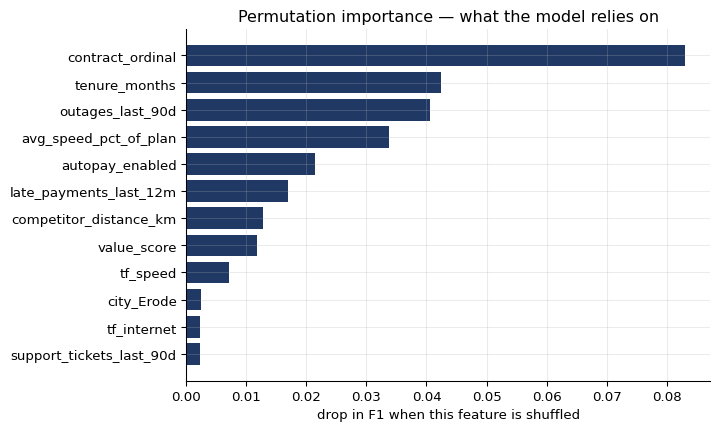

               feature  importance
      contract_ordinal      0.0831
         tenure_months      0.0424
      outages_last_90d      0.0407
 avg_speed_pct_of_plan      0.0337
       autopay_enabled      0.0215
late_payments_last_12m      0.0170
competitor_distance_km      0.0127
           value_score      0.0118
              tf_speed      0.0071
            city_Erode      0.0025


In [30]:
from sklearn.inspection import permutation_importance

# ---- 14.1 Permutation importance: works for ANY model ----
perm = permutation_importance(champion, X_test, y_test, n_repeats=8,
                              random_state=RANDOM_STATE, scoring="f1", n_jobs=-1)
pi = pd.DataFrame({"feature": X_test.columns,
                   "importance": perm.importances_mean}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
top12 = pi.head(12).iloc[::-1]
ax.barh(top12.feature, top12.importance, color="#1F3864")
ax.set_title("Permutation importance — what the model relies on")
ax.set_xlabel("drop in F1 when this feature is shuffled")
plt.tight_layout(); plt.show()

print(pi.head(10).round(4).to_string(index=False))

SHAP — mean absolute contribution to the churn prediction
                 feature  mean_abs_shap
        contract_ordinal         0.0829
           tenure_months         0.0554
   avg_speed_pct_of_plan         0.0430
         autopay_enabled         0.0274
  competitor_distance_km         0.0265
                 segment         0.0250
        outages_last_90d         0.0218
             value_score         0.0216
  days_since_last_ticket         0.0117
  late_payments_last_12m         0.0113
support_tickets_last_90d         0.0094
           gb_per_device         0.0082


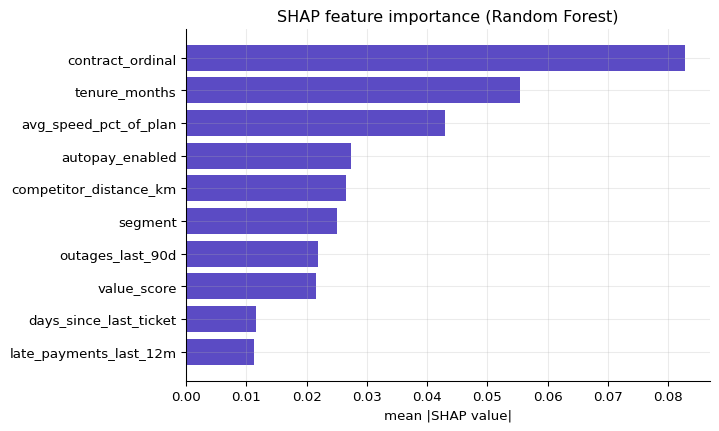

In [31]:
# ---- 14.2 SHAP on the Random Forest (tree models give exact SHAP values) ----
try:
    import shap
    rf = fitted["Random Forest"]
    explainer = shap.TreeExplainer(rf)
    sample = X_test.sample(min(300, len(X_test)), random_state=1)
    sv = explainer.shap_values(sample)

    # normalise shape across shap versions: we want the churn (class 1) contributions
    if isinstance(sv, list):
        sv_churn = sv[1]
    elif getattr(sv, "ndim", 2) == 3:
        sv_churn = sv[:, :, 1]
    else:
        sv_churn = sv

    shap_imp = pd.DataFrame({
        "feature": sample.columns,
        "mean_abs_shap": np.abs(sv_churn).mean(axis=0)}).sort_values("mean_abs_shap", ascending=False)

    print("SHAP — mean absolute contribution to the churn prediction")
    print("="*62)
    print(shap_imp.head(12).round(4).to_string(index=False))

    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    t10 = shap_imp.head(10).iloc[::-1]
    ax.barh(t10.feature, t10.mean_abs_shap, color="#5B4BC4")
    ax.set_title("SHAP feature importance (Random Forest)")
    ax.set_xlabel("mean |SHAP value|")
    plt.tight_layout(); plt.show()
    SHAP_OK = True
except Exception as err:
    print("SHAP unavailable in this environment:", err)
    print("Falling back to the permutation importance above, which conveys the same idea.")
    SHAP_OK = False

In [32]:
# ---- 14.3 Explaining ONE subscriber — what the agent actually reads ----
if SHAP_OK:
    # Pick the subscriber the model is MOST worried about - the one who would actually
    # be on the retention team's call list this month. Ranking by total |SHAP| instead
    # finds the subscriber with the LARGEST EXPLANATION, which is easily a confidently
    # SAFE one: a different question, and not the one an agent needs answered.
    risk = rf.predict_proba(sample)[:, 1]
    idx = int(np.argmax(risk))
    person = sample.iloc[idx]
    contrib = pd.Series(sv_churn[idx], index=sample.columns).sort_values(key=np.abs, ascending=False)

    print("REASON CODES FOR ONE SUBSCRIBER")
    print("="*66)
    print(f"Predicted churn probability: {risk[idx]:.1%}  (highest in this sample)\n")
    print("Top factors pushing this prediction:")
    for f, v in contrib.head(6).items():
        direction = "increases risk" if v > 0 else "reduces risk"
        print(f"   {f:<28} {v:+.4f}   {direction}   (value = {person[f]:g})")

    print("\n>>> This is what makes the model deployable. The retention agent never reads")
    print(">>> 'the model said so' - they read the lines above and open the call with the")
    print(">>> specific thing that is wrong: the contract, the outages, or the speed this")
    print(">>> subscriber is paying for and not getting.")

REASON CODES FOR ONE SUBSCRIBER
Predicted churn probability: 72.0%  (highest in this sample)

Top factors pushing this prediction:
   contract_ordinal             +0.0732   increases risk   (value = 0)
   avg_speed_pct_of_plan        +0.0664   increases risk   (value = 73.7)
   tenure_months                +0.0443   increases risk   (value = 10)
   segment                      +0.0436   increases risk   (value = 2)
   autopay_enabled              +0.0249   increases risk   (value = 0)
   competitor_distance_km       -0.0210   reduces risk   (value = 2.44)

>>> This is what makes the model deployable. The retention agent never reads
>>> 'the model said so' - they read the lines above and open the call with the
>>> specific thing that is wrong: the contract, the outages, or the speed this
>>> subscriber is paying for and not getting.


> ### Fairness check before deployment
>
> The model never sees caste, religion, gender or income. **That is not sufficient.** `city`,
> `plan_price_inr` and `competitor_distance_km` can act as **proxies** for neighbourhood and income, so
> a model blind to protected attributes can still produce discriminatory outcomes through them.
>
> Before launch, NILA should audit contact rates and offer generosity across cities and plan tiers, and
> ask whether any observed difference is justified by genuine risk rather than by a proxy. This audit
> would repeat quarterly, not once.

# 15 · Deployment
### *Module 5 — a notebook is a demo; production is a commitment*

In [33]:
# ---- 15.1 Drift monitoring: what we would watch every month ----
# Simulate "next month" by shifting a few inputs the way a real quarter would
live = X_test.copy()
SHIFTS = {"outages_last_90d": 1.9,        # monsoon
          "avg_speed_pct_of_plan": 0.93,  # network congestion
          "competitor_distance_km": 0.6}  # a rival expanded nearby
for col, mult in SHIFTS.items():
    if col in live.columns:
        live[col] = live[col] * mult

# monitor whatever actually survived feature selection
WATCH = [c for c in ["tenure_months","outages_last_90d","avg_speed_pct_of_plan",
                     "competitor_distance_km","late_payments_last_12m","data_gb_log"]
         if c in X_train.columns][:5]
print("DRIFT MONITOR — training baseline vs simulated live month")
print("="*76)
print(f"{'Feature':<28}{'Training':>12}{'Live':>12}{'Change %':>11}{'Flag':>9}")
print("-"*76)
for f in WATCH:
    a, b = X_train[f].mean(), live[f].mean()
    pct = (b-a)/a*100
    flag = "ALERT" if abs(pct) > 30 else ("watch" if abs(pct) > 12 else "stable")
    print(f"{f:<28}{a:>12.2f}{b:>12.2f}{pct:>+10.1f}%{flag:>9}")

print("\n>>> Nothing here raises an error. The model keeps returning confident")
print(">>> predictions built on relationships learned in different conditions.")
print(">>> This is why you monitor INPUTS, not just wait for performance to drop.")

DRIFT MONITOR — training baseline vs simulated live month
Feature                         Training        Live   Change %     Flag
----------------------------------------------------------------------------
tenure_months                      21.69       22.48      +3.7%   stable
outages_last_90d                    1.10        2.07     +88.9%    ALERT
avg_speed_pct_of_plan              85.87       80.16      -6.6%   stable
competitor_distance_km              2.42        1.46     -39.4%    ALERT
late_payments_last_12m              0.68        0.69      +1.4%   stable

>>> Nothing here raises an error. The model keeps returning confident
>>> predictions built on relationships learned in different conditions.
>>> This is why you monitor INPUTS, not just wait for performance to drop.


In [34]:
# ---- 15.2 Model card: the document that ships with the model ----
model_card = {
 "model_name":       "NILA Broadband churn scorecard v1.0",
 "owner":            "Analytics team, reviewed by COO office",
 "purpose":          "Rank subscribers by 30-day churn risk to allocate a capped retention budget",
 "algorithm":        "Logistic Regression with balanced class weights, standardised inputs",
 "training_rows":    int(len(X_train)),
 "features":         int(X_train.shape[1]),
 "test_auc":         round(float(auc), 3),
 "test_recall":      round(float(recall_score(y_test, pred_default)), 3),
 "ks_statistic":     float(dec.KS.max()),
 "decile1_lift":     float(dec.lift.iloc[0]),
 "recommended_threshold": float(best[0]),
 "expected_net_return_per_1000_subscribers":
        round(float(best[1] / len(y_test) * 1000)),
 "known_limitations": [
   "Trained on a cross-sectional snapshot; no seasonality captured",
   "Autopay association may be a marker of commitment, not a cause",
   "Text features assume clean English; real tickets are code-mixed",
   "No data on subscribers who left before the observation window (survivorship)",
 ],
 "review_due": "90 days from deployment, or on any ALERT from the drift monitor",
}
print("MODEL CARD")
print("="*66)
for k, v in model_card.items():
    if isinstance(v, list):
        print(f"{k}:")
        for item in v: print(f"    - {item}")
    else:
        print(f"{k:<42} {v}")

MODEL CARD
model_name                                 NILA Broadband churn scorecard v1.0
owner                                      Analytics team, reviewed by COO office
purpose                                    Rank subscribers by 30-day churn risk to allocate a capped retention budget
algorithm                                  Logistic Regression with balanced class weights, standardised inputs
training_rows                              4500
features                                   64
test_auc                                   0.77
test_recall                                0.698
ks_statistic                               41.5
decile1_lift                               3.29
recommended_threshold                      0.5
expected_net_return_per_1000_subscribers   184000
known_limitations:
    - Trained on a cross-sectional snapshot; no seasonality captured
    - Autopay association may be a marker of commitment, not a cause
    - Text features assume clean English; real tickets a

In [35]:
# ---- 15.3 Persist the artefacts needed to score a new subscriber ----
import joblib, os

os.makedirs("nila_model", exist_ok=True)
joblib.dump(champion,      "nila_model/churn_model.joblib")
joblib.dump(tfidf_vec,     "nila_model/tfidf_vectorizer.joblib")
joblib.dump(kmeans,        "nila_model/segment_kmeans.joblib")
joblib.dump(seg_scaler,    "nila_model/segment_scaler.joblib")
joblib.dump(list(X_train.columns), "nila_model/feature_order.joblib")

print("Saved to ./nila_model/ :")
for f in sorted(os.listdir("nila_model")):
    print(f"   {f:<32}{os.path.getsize(os.path.join('nila_model',f)):>10,} bytes")

# Prove the saved model reloads and reproduces the same predictions
reloaded = joblib.load("nila_model/churn_model.joblib")
assert np.allclose(reloaded.predict_proba(X_test)[:,1], proba), "reloaded model differs!"
print("\n>>> Reload test PASSED - saved model reproduces identical predictions.")
print(">>> Note we save the VECTORISER and SCALER too. A model without the exact")
print(">>> transformers used to train it cannot score a new subscriber correctly.")

Saved to ./nila_model/ :
   churn_model.joblib                   4,830 bytes
   feature_order.joblib                   942 bytes
   segment_kmeans.joblib               24,887 bytes
   segment_scaler.joblib                1,119 bytes
   tfidf_vectorizer.joblib              2,191 bytes

>>> Reload test PASSED - saved model reproduces identical predictions.
>>> Note we save the VECTORISER and SCALER too. A model without the exact
>>> transformers used to train it cannot score a new subscriber correctly.


# 16 · Recommendation and Limitations

---

## Memo to Ms. Lakshmi Narayanan, Chief Operating Officer

**Subject: Subscriber churn model — recommendation**

**Adopt the model and target the top three deciles.** On 1,500 held-out subscribers the model ranks
churn risk reliably: the riskiest decile churns at 56.7% against a book average of 17.2% — a lift of 3.29 — and contacting
the top 30% of the ranked list reaches 63.2% of all churners. The KS statistic of 41.5 places this in
the accepted band for a first-generation scorecard.

**Contact subscribers above the profit-optimal threshold identified in section 13, not every subscriber
the model flags.** This is the counter-intuitive finding. Targeting aggressively enough to catch nearly
every churner turns the campaign **loss-making**, because each unnecessary offer costs ₹1,200 and the
volume of loyal subscribers contacted overwhelms the value of those saved.

**Three service actions fall out of the model independently of any campaign.** Contract type, outages
and delivered speed are the strongest drivers. Moving month-to-month subscribers onto annual contracts,
and fixing lines running below 75% of their promised speed, addresses churn at source rather than
buying it back one discount at a time.

---

## What I would not claim

**This is a snapshot, not a history.** One observation per subscriber, no seasonality, no view of how
risk evolves. A panel of monthly observations would support a far better model and would require a
time-based split.

**Survivorship bias.** We only see subscribers who existed at the snapshot. Anyone who churned before
the observation window is invisible, so the model may understate risk in the earliest tenure months.

**Autopay is an association, not an established cause.** Autopay subscribers churn far less, but
enabling autopay may simply be what committed subscribers do. Forcing it on everybody would likely not
transfer the effect. Only a controlled experiment would settle it.

**The text features are unrealistically clean.** Real NILA tickets would be code-mixed Tamil and
English with transliteration and emoji, and an English-only pipeline would silently discard a segment
of subscribers.

**Proxy discrimination is possible and untested.** The model never sees protected attributes, but city
and plan price can stand in for neighbourhood and income. The fairness audit in section 14 is required
before launch, not after.

---

## What the next version would need

| Priority | Change | Why |
|---|---|---|
| 1 | Monthly panel data rather than a snapshot | Enables time-based validation and captures how risk builds |
| 2 | A holdout control group in the campaign | The only way to measure whether offers actually save anyone |
| 3 | Multilingual text handling | Recovers a segment currently invisible to the model |
| 4 | Cost-sensitive learning rather than post-hoc thresholding | Optimises the rupee objective directly |
| 5 | Quarterly fairness and drift audit, automated | Neither issue announces itself |

---

## Checklist — what made this a capstone rather than a modelling exercise

- [x] A business decision defined before any data was touched, with the cost of each error quantified
- [x] Data provenance stated honestly, including that the data is simulated
- [x] A full audit: fill rate, descriptives, target balance, distributions
- [x] Three different missing-data problems handled three different ways, each justified
- [x] All four feature engineering stages, in the taught order
- [x] Text converted into model features, with the real-world caveat stated
- [x] Unsupervised learning used *inside* a supervised pipeline
- [x] An explicit leakage audit, feature by feature
- [x] A naive baseline built **before** any model, and every model held against it
- [x] Cross-validation with the spread reported, and tuning done off the test set
- [x] Confusion matrix, threshold sweep, ROC, gain, decile and KS
- [x] The model converted into rupees, including where it **loses** money
- [x] Explainability down to reason codes for one individual subscriber
- [x] A fairness check, a drift monitor, a model card and saved artefacts
- [x] Limitations stated plainly, including the ones that weaken the conclusion

---

*Bharathidasan Institute of Management · AI and Machine Learning · Term 4*
*NILA Broadband is a fictional company. The dataset is simulated with a fixed seed so that every
figure in this notebook is reproducible.*